In [2]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt


# Mumford - Shah Functional

## Mumford - Shah Funtional in 1D when K is empty

In [96]:
delta_x = 0.01
rho = 500
eps = 250
b = 1
a = 2

In [ ]:
def u_exact(x):
    if x < 0:
        return exp(2)

In [ ]:

def u_exact:



u(x) = \begin{cases}
        \frac{e^{2\sqrt{2}}}{1+e^{2\sqrt{2}}}e^{nx}+\frac{1}{1+e^{2\sqrt{2}}}e^{-\sqrt{2}x} - 1 & x \in[-1, 0)\\
        \frac{-1}{1+e^{2\sqrt{2}}}e^{\sqrt{2}x}-\frac{e^{2\sqrt{2}}}{1+e^{2\sqrt{2}}}e^{-\sqrt{2}x} + 1 & x \in[0, 1]

In [97]:
def weighted_sum(u, alpha):
    weights = (1 - alpha)**2  # elementwise, 
    diffs = u[1:] - u[:-1]   # u_{i+1} - u_i, shape (n-1,)
    return 1/2 * (cp.sum(cp.multiply(weights, cp.square(diffs))) / delta_x)



In [98]:
# Set-up

def Argmin_u_update(alpha):
    u = cp.Variable(201)
    u_1 = u[:101]
    u_2 = u[101:-1]
    objective = cp.Minimize(weighted_sum(u, alpha) + delta_x * b *  cp.sum_squares(u_1 +1) + delta_x *b * cp.sum_squares(u_2 - 1))
    prob = cp.Problem(objective)
    prob.solve()
    return u.value

def Argmin_alpha_update(u, beta, w):
    alpha = cp.Variable(200)
    objective = cp.Minimize(weighted_sum(u, alpha) + rho/2 *cp.sum_squares(alpha - beta + w))
    constraints = [alpha[0] == 0, alpha >= 0, alpha <= 1]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return alpha.value

def Argmin_beta_update(alpha, w):
    beta = cp.Variable(200)
    objective = cp.Minimize(a /2 * (delta_x / eps * cp.sum_squares(beta) + eps / delta_x * cp.sum_squares(beta[1:] - beta[:-1])) + rho/2 * cp.sum_squares(alpha - beta + w))
    constraints = [beta >= alpha]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return beta.value




In [93]:
# ADMM

alpha = np.zeros(200)
beta = np.zeros(200)
w = np.zeros(200)

r_norm = []
s_norm = []

r_tol = 10e-4
s_tol = 10e-4

r_new = 10e5
s_new = 10e5

num_iter = 0

while r_tol < r_new or s_tol < s_new:
    beta_old = beta.copy()
    u = Argmin_u_update(alpha) # u^{k+1}
    alpha = Argmin_alpha_update(u, beta, w) # alpha^{k+1}
    beta = Argmin_beta_update(alpha, w) # beta^{k+1}
    w = w + alpha - beta # w^{k+1}

    r = alpha - beta # primal residual
    r_new = np.linalg.norm(r)
    r_norm.append(r_new)

    s = rho * (beta - beta_old) # dual redisual
    s_new = np.linalg.norm(s)
    s_norm.append(s_new)

    num_iter +=1


r_norm = np.array(r_norm)
s_norm = np.array(s_norm)
print(f"{num_iter} iterations needed for convergence")

647 iterations needed for convergence


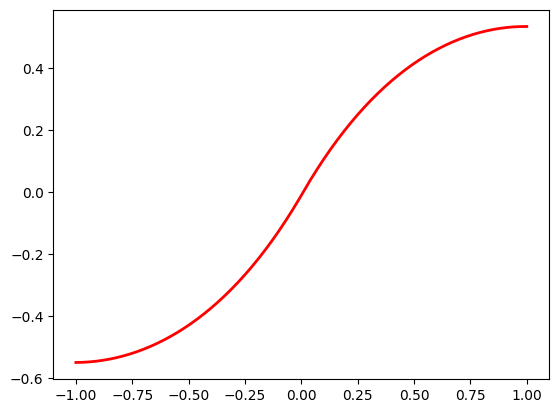

In [100]:
# Alternating Minimization

alpha = np.zeros(200)

def Argmin_alpha_update_AM(u):
    alpha = cp.Variable(200)
    u_1 = u[:101]
    u_2 = u[101:-1]
    objective = cp.Minimize(weighted_sum(u, alpha) + delta_x * b *  cp.sum_squares(u_1 +1) + delta_x *b * cp.sum_squares(u_2 - 1) 
                            + a /2 * (delta_x / eps * cp.sum_squares(alpha) + eps / delta_x * cp.sum_squares(alpha[1:] - alpha[:-1])))
    constraints = [alpha[0] == 0, alpha >= 0, alpha <= 1]
    prob = cp. Problem(objective, constraints)
    prob.solve()
    return alpha.value


for _ in range(1000):
    u = Argmin_u_update(alpha)
    alpha = Argmin_alpha_update_AM(u)

plt.close('all')
fig, ax = plt.subplots()
ax.plot(np.linspace(-1, 1, 201), u, linewidth = 2, color = 'red', label = r'$u$')



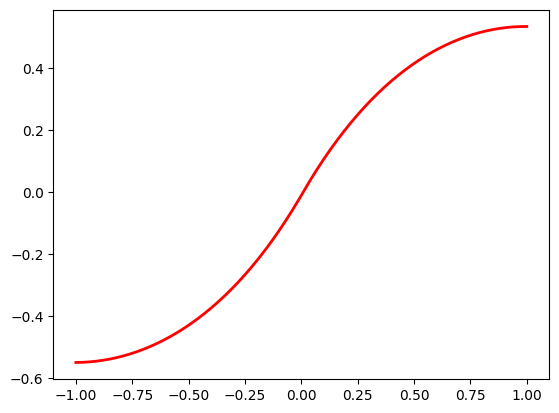

In [94]:
plt.close('all')
fig, ax = plt.subplots()
ax.plot(np.linspace(-1, 1, 201), u, linewidth = 2, color = 'red', label = r'$u$')


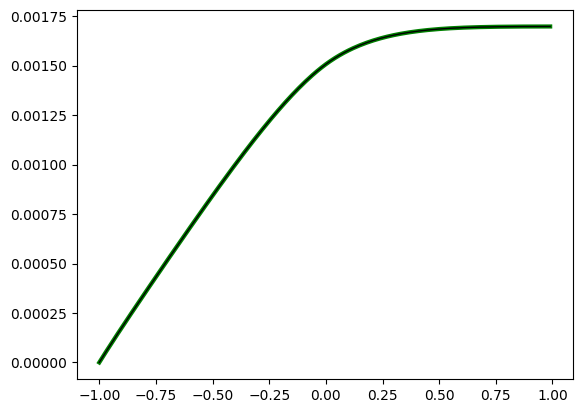

In [95]:
plt.close('all')
fig, ax = plt.subplots()
ax.plot(np.linspace(-1, 0.99, 200), alpha, linewidth = 3, color = 'green', label = r'$\alpha$')
ax.plot(np.linspace(-1, 0.99, 200), beta, linewidth = 1, color = 'black', label = r'$\beta$')

In [58]:
print(len(alpha))
print(len(beta))
print(len(u))

200
200
201
